In [2]:
!pip install pesq nolds

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 2.5 MB/s eta 0:00:00
  Created wheel for pesq: filename=pesq-0.0.4-cp313-cp313-linux_x86_64.whl size=279152 sha256=a4185ebb70dc7540988383afd288cc8ed5f146ea0e5b8167710df5c8fcea6a76
  Stored in directory: /root/.cache/pip/wheels/7f/fd/bd/0db325a6b4eee46eb45834f881c452d8b651e8ee8dc86546f9
Successfully built pesq


In [3]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nolds

from pesq        import pesq as pesq_fn
from scipy       import stats
from scipy.integrate import odeint
from math        import factorial, log2

warnings.filterwarnings("ignore")
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


In [13]:
!wget -q "https://www.openslr.org/resources/12/test-clean.tar.gz" \
      -O test-clean.tar.gz --show-progress

!tar -xzf test-clean.tar.gz \
    --wildcards "*.flac" 2>/dev/null || true

import glob as glob_module

all_flac = glob_module.glob("LibriSpeech/test-clean/**/**/*.flac")
print(f"Total files found: {len(all_flac)}")

# Sort by duration longest first, take top 50
all_files = sorted(
    all_flac,
    key=lambda f: librosa.get_duration(path=f),
    reverse=True
)[:50]

print(f"\nSelected {len(all_files)} files")
print(f"Longest  file : {librosa.get_duration(path=all_files[0]):.2f}s")
print(f"Shortest file : {librosa.get_duration(path=all_files[-1]):.2f}s")
print(f"All above 3s  : {all(librosa.get_duration(path=f) > 3 for f in all_files)}")
print("\nSelected files:")
for i, f in enumerate(all_files):
    dur = librosa.get_duration(path=f)
    print(f"  [{i+1:02d}] {os.path.basename(f):40s} {dur:.2f}s")

test-clean.tar.gz   100%[===================>] 330.60M  13.9MB/s    in 27s     
Total files found: 2620

Selected 50 files
Longest  file : 34.95s
Shortest file : 22.29s
All above 3s  : True

Selected files:
  [01] 4507-16021-0047.flac                     34.95s
  [02] 1995-1836-0004.flac                      33.91s
  [03] 7021-79730-0003.flac                     32.88s
  [04] 908-157963-0007.flac                     32.77s
  [05] 2094-142345-0008.flac                    31.65s
  [06] 4507-16021-0026.flac                     31.61s
  [07] 672-122797-0008.flac                     30.81s
  [08] 2094-142345-0010.flac                    30.61s
  [09] 121-123859-0002.flac                     30.04s
  [10] 4970-29093-0006.flac                     29.60s
  [11] 5105-28241-0015.flac                     29.14s
  [12] 3729-6852-0033.flac                      28.57s
  [13] 5639-40744-0031.flac                     28.42s
  [14] 4992-41797-0001.flac                     28.41s
  [15] 8224-274381-0009

In [5]:
NOISE_NAMES = [
    "logistic", "skew_tent", "henon", "bernoulli", "ikeda",
    "lorenz",   "rossler",   "chen",  "mackey_glass", "duffing"
]

def make_noise(name, n_samples):
    """
    Generate one chaotic noise signal of length n_samples.
    ODE-based systems are solved at 3000 points then tiled
    to avoid RAM crashes from large ODE arrays.
    """

    if name == "logistic":
        x = np.zeros(n_samples); x[0] = 0.4
        for i in range(1, n_samples):
            x[i] = 4 * x[i-1] * (1 - x[i-1])
        return x - x.mean()

    elif name == "skew_tent":
        a = 0.3
        x = np.zeros(n_samples); x[0] = 0.4
        for i in range(1, n_samples):
            x[i] = x[i-1]/a if x[i-1] < a else (1 - x[i-1])/(1 - a)
        return x - x.mean()

    elif name == "henon":
        x = np.zeros(n_samples); y = np.zeros(n_samples)
        x[0], y[0] = 0.1, 0.1
        for i in range(1, n_samples):
            x[i] = 1 - 1.4*x[i-1]**2 + y[i-1]
            y[i] = 0.3 * x[i-1]
        return x - x.mean()

    elif name == "bernoulli":
        x = np.zeros(n_samples); x[0] = 0.3
        for i in range(1, n_samples):
            x[i] = (2 * x[i-1]) % 1
        return x - x.mean()

    elif name == "ikeda":
        from cmath import exp as cexp
        z = complex(0.1, 0.1); zs = []
        for _ in range(n_samples):
            t = 0.4 - 6/(1 + abs(z)**2)
            z = 1 + 0.9 * z * cexp(complex(0, t))
            zs.append(z.real)
        arr = np.array(zs)
        return arr - arr.mean()

    elif name == "lorenz":
        def f(s, t):
            x,y,z = s
            return [10*(y-x), x*(28-z)-y, x*y-(8/3)*z]
        t   = np.linspace(0, 30, 3000)
        sol = odeint(f, [1,1,1], t)
        sig = sol[:,0] - sol[:,0].mean()
        return np.tile(sig, int(np.ceil(n_samples/len(sig))))[:n_samples]

    elif name == "rossler":
        def f(s, t):
            x,y,z = s
            return [-(y+z), x+0.2*y, 0.2+z*(x-5.7)]
        t   = np.linspace(0, 100, 3000)
        sol = odeint(f, [0.1,0.1,0.1], t)
        sig = sol[:,0] - sol[:,0].mean()
        return np.tile(sig, int(np.ceil(n_samples/len(sig))))[:n_samples]

    elif name == "chen":
        def f(s, t):
            x,y,z = s
            return [35*(y-x), -7*x - x*z + 28*y, x*y - 3*z]
        t   = np.linspace(0, 30, 3000)
        sol = odeint(f, [1,1,1], t)
        sig = sol[:,0] - sol[:,0].mean()
        return np.tile(sig, int(np.ceil(n_samples/len(sig))))[:n_samples]

    elif name == "mackey_glass":
        x = np.ones(n_samples) * 1.2; tau = 17
        for i in range(tau, n_samples):
            x[i] = (x[i-1]
                    + (0.2*x[i-tau])/(1 + x[i-tau]**10)
                    - 0.1*x[i-1])
        return x - x.mean()

    elif name == "duffing":
        def f(s, t):
            x,v = s
            return [v, -0.3*v + x - x**3 + 0.4*np.cos(1.2*t)]
        t   = np.linspace(0, 200, 3000)
        sol = odeint(f, [0.1,0.1], t)
        sig = sol[:,0] - sol[:,0].mean()
        return np.tile(sig, int(np.ceil(n_samples/len(sig))))[:n_samples]

print(f"Noise generator ready. Systems: {NOISE_NAMES}")

Noise generator ready. Systems: ['logistic', 'skew_tent', 'henon', 'bernoulli', 'ikeda', 'lorenz', 'rossler', 'chen', 'mackey_glass', 'duffing']


In [6]:
SNR_LEVELS = [-10, -5, 0, 5, 10]

def mix_at_snr(clean, noise, snr_db):
    """Mix clean speech and noise at a target SNR in dB."""
    noise        = noise[:len(clean)]
    signal_power = np.mean(clean**2)
    noise_power  = np.mean(noise**2) + 1e-12
    scale        = np.sqrt(signal_power / (noise_power * 10**(snr_db/10)))
    return (clean + scale * noise).astype(np.float32)

print("SNR mixer ready.")

SNR mixer ready.


In [14]:
def get_segment(signal, sr=16000, target_len=3000):
    """
    Extract target_len consecutive samples from the middle of the signal.
    All files are guaranteed long so no edge cases needed.
    """
    signal = signal / (np.std(signal) + 1e-9)
    mid    = len(signal) // 2
    start  = max(0, mid - target_len // 2)
    return signal[start : start + target_len].astype(np.float64)


def perm_entropy(x, order=5, delay=1):
    """
    Permutation Entropy.
    Measures rank-order randomness of a signal.
    Returns 0 (perfectly regular) to 1 (maximally random).
    Chaotic systems land between 0.3 and 0.98.
    """
    counts = {}
    for i in range(len(x) - delay*(order-1)):
        window  = x[i : i + delay*order : delay]
        pattern = tuple(np.argsort(window))
        counts[pattern] = counts.get(pattern, 0) + 1
    total = sum(counts.values())
    probs = np.array(list(counts.values())) / total
    return -np.sum(probs * np.log2(probs + 1e-12)) / log2(factorial(order))


def recurrence_rate(x, emb_dim=3, lag=1, threshold=0.8):
    """
    Recurrence Rate.
    Measures how often the signal revisits a past state.
    Deterministic chaos : 0.05 – 0.40
    Random noise        : 0.01 – 0.05
    """
    N      = len(x)
    states = np.array([
        x[i : i + emb_dim*lag : lag]
        for i in range(N - (emb_dim-1)*lag)
    ])
    M   = len(states)
    idx = np.random.choice(M, size=min(M, 600), replace=False)

    count = 0
    total = 0
    for i in range(len(idx)):
        for j in range(i+1, len(idx)):
            dist   = np.max(np.abs(states[idx[i]] - states[idx[j]]))
            total += 1
            if dist < threshold:
                count += 1
    return count / total if total > 0 else 0.0

print("Helper functions ready.")

Helper functions ready.


In [25]:
from scipy.spatial import cKDTree

def estimate_delay_ami(signal, max_delay=50, bins=32):
    """
    Find optimal time delay (tau) using the first local minimum
    of the Average Mutual Information (AMI).
    """
    ami = []
    for tau in range(1, max_delay + 1):
        x = signal[:-tau]
        y = signal[tau:]

        hist_xy, _, _ = np.histogram2d(x, y, bins=bins)
        p_xy = hist_xy / np.sum(hist_xy)
        p_x = np.sum(p_xy, axis=1)
        p_y = np.sum(p_xy, axis=0)

        mask = p_xy > 0
        mi = np.sum(p_xy[mask] * np.log2(p_xy[mask] / (p_x[:, None] * p_y[None, :])[mask]))
        ami.append(mi)

    for i in range(1, len(ami) - 1):
        if ami[i-1] > ami[i] and ami[i] < ami[i+1]:
            return i + 1

    return np.argmin(ami) + 1

def estimate_dimension_fnn(signal, delay, max_dim=10, r_tol=15, a_tol=2):
    """
    Find optimal embedding dimension (m) using False Nearest Neighbors.
    Stops when false neighbors drop below 5%.
    """
    r_a = np.std(signal)

    for m in range(1, max_dim + 1):
        n_points = len(signal) - m * delay
        if n_points < 100:
            break

        embed_m = np.array([signal[i : i + m * delay : delay] for i in range(n_points)])

        tree = cKDTree(embed_m)
        distances_m, indices = tree.query(embed_m, k=2, p=2)
        dist_m = distances_m[:, 1]
        nn_idx = indices[:, 1]

        false_neighbors = 0
        valid_points = 0

        for i in range(n_points):
            idx_point_next = i + m * delay
            idx_nn_next = nn_idx[i] + m * delay

            if idx_point_next < len(signal) and idx_nn_next < len(signal):
                valid_points += 1
                dist_next_dim = np.abs(signal[idx_point_next] - signal[idx_nn_next])

                is_false_1 = (dist_next_dim / (dist_m[i] + 1e-10)) > r_tol
                dist_m1 = np.sqrt(dist_m[i]**2 + dist_next_dim**2)
                is_false_2 = (dist_m1 / r_a) > a_tol

                if is_false_1 or is_false_2:
                    false_neighbors += 1

        fnn_ratio = false_neighbors / max(valid_points, 1)

        if fnn_ratio < 0.05 or m == max_dim:
            return m

    return max_dim

In [34]:
def compute_csi(signal, sr=16000):
    """
    Compute Chaos Signature Index directly on any audio signal (clean or noisy).
    Calculates dynamic embedding parameters for topological accuracy.
    """
    seg = get_segment(signal, sr=sr, target_len=3000)

    opt_delay = estimate_delay_ami(seg, max_delay=50)
    opt_dim   = estimate_dimension_fnn(seg, delay=opt_delay, max_dim=8)

    perm_dim = min(opt_dim, 6)

    raw = {}

    try:
        raw["PermEn"] = perm_entropy(seg, order=perm_dim, delay=opt_delay)
    except:
        raw["PermEn"] = np.nan

    try:
        raw["D2"] = nolds.corr_dim(
            seg, emb_dim=opt_dim, lag=opt_delay,
            rvals=np.logspace(-0.5, 0.8, 25)
        )
    except:
        raw["D2"] = np.nan

    try:
        raw["SampEn"] = nolds.sampen(
            seg, emb_dim=2,
            tolerance=0.2 * np.std(seg)
        )
    except:
        raw["SampEn"] = np.nan

    try:
        raw["RR"] = recurrence_rate(seg, emb_dim=opt_dim, lag=opt_delay, threshold=0.8)
    except:
        raw["RR"] = np.nan

    components = {}

    perm_val = raw.get("PermEn", np.nan)
    d2_val   = raw.get("D2", np.nan)
    samp_val = raw.get("SampEn", np.nan)
    rr_val   = raw.get("RR", np.nan)

    if not np.isnan(perm_val):
        components["struct"] = 1.0 - perm_val

    if not np.isnan(d2_val):
        components["attractor"] = 1.0 / (d2_val + 1.0)

    if not np.isnan(samp_val):
        components["predict"] = 1.0 / (samp_val + 1.0)

    if not np.isnan(rr_val):
        # ── BIOLOGICAL CONSTRAINT PENALTY ──────────────────────────────
        # Natural speech maintains a balance between entropy and recurrence.
        # If entropy is extreme (>0.90) but RR is also high, it is a binary artifact.
        if perm_val > 0.90:
            # Scale the false RR down using the tiny structure value
            components["recur"] = rr_val * (1.0 - perm_val)
        else:
            components["recur"] = rr_val

    vals = list(components.values())
    csi  = float(np.mean(vals)) if vals else np.nan

    return {**raw, "CSI": csi, "tau": opt_delay, "m": opt_dim}

print("compute_csi loaded.")

compute_csi loaded.


In [39]:
all_results  = []
orig_results = []
SR           = 16000

for file_idx, filepath in enumerate(all_files):
    fname = os.path.basename(filepath)
    print(f"\n{'='*60}")
    print(f"File {file_idx+1:02d}/50: {fname}")

    # Load file
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    print(f"  Duration : {len(audio)/SR:.2f}s  ({len(audio)} samples)")

    # ── Original clean audio evaluation
    # Pass the clean signal straight into the unified compute_csi
    pesq_orig = pesq_fn(SR, audio, audio, 'wb')
    csi_orig  = compute_csi(audio, sr=SR)

    orig_results.append({
        "file"   : fname,
        "PESQ"   : round(pesq_orig,           4),
        "PermEn" : round(csi_orig["PermEn"],  4),
        "D2"     : round(csi_orig["D2"],      4),
        "RR"     : round(csi_orig["RR"],      4),
        "tau"    : csi_orig["tau"],
        "m"      : csi_orig["m"],
        "CSI"    : round(csi_orig["CSI"],     4),
    })
    print(f"  Clean   → PESQ={pesq_orig:.3f} | CSI={csi_orig['CSI']:.3f} | tau={csi_orig['tau']}, m={csi_orig['m']}")

    # ── Noisy conditions evaluation
    for noise_name in NOISE_NAMES:
        noise_sig = make_noise(noise_name, len(audio))

        for snr in SNR_LEVELS:
            noisy = mix_at_snr(audio, noise_sig, snr)

            try:
                pesq_score = pesq_fn(SR, audio, noisy, 'wb')
            except:
                pesq_score = np.nan

            # Pass the noisy signal directly into compute_csi.
            # Delete the residual subtraction logic.
            csi = compute_csi(noisy, sr=SR)

            all_results.append({
                "file"   : fname,
                "noise"  : noise_name,
                "snr"    : snr,
                "PESQ"   : round(pesq_score,    4),
                "PermEn" : round(csi["PermEn"], 4),
                "D2"     : round(csi["D2"],     4),
                "RR"     : round(csi["RR"],     4),
                "tau"    : csi["tau"],
                "m"      : csi["m"],
                "CSI"    : round(csi["CSI"],    4),
            })

        del noise_sig, noisy
        print(f"  {noise_name:15s} done")

    del audio

    pd.DataFrame(all_results).to_csv("results_progress.csv", index=False)
    pd.DataFrame(orig_results).to_csv("orig_progress.csv",   index=False)
    print(f"  Saved. ({file_idx+1}/{len(all_files)} complete)")

df      = pd.DataFrame(all_results)
df_orig = pd.DataFrame(orig_results)

print(f"\n{'='*60}")
print(f"DONE.  Noisy rows : {len(df)}   |   Clean rows : {len(df_orig)}")

nan_report = df[["PESQ","CSI","PermEn","D2","RR"]].isna().sum()
print(f"\nNaN counts:\n{nan_report}")


File 01/50: 4507-16021-0047.flac
  Duration : 34.95s  (559280 samples)
  Clean   → PESQ=4.644 | CSI=0.297 | tau=9, m=4
  logistic        done
  skew_tent       done
  henon           done
  bernoulli       done
  ikeda           done
  lorenz          done
  rossler         done
  chen            done
  mackey_glass    done
  duffing         done
  Saved. (1/50 complete)

File 02/50: 1995-1836-0004.flac
  Duration : 33.91s  (542560 samples)
  Clean   → PESQ=4.644 | CSI=0.251 | tau=11, m=4
  logistic        done
  skew_tent       done
  henon           done
  bernoulli       done
  ikeda           done
  lorenz          done
  rossler         done
  chen            done
  mackey_glass    done
  duffing         done
  Saved. (2/50 complete)

File 03/50: 7021-79730-0003.flac
  Duration : 32.88s  (526080 samples)
  Clean   → PESQ=4.644 | CSI=0.665 | tau=6, m=8
  logistic        done
  skew_tent       done
  henon           done
  bernoulli       done
  ikeda           done
  lorenz       

In [44]:
# Define all metrics to track
metrics = ["PESQ", "CSI", "PermEn", "D2", "RR"]

# 1. Aggregate noisy data for all metrics simultaneously
agg_funcs = {m: ["mean", "std", "count"] for m in metrics}
summary = df.groupby(["noise", "snr"]).agg(agg_funcs).reset_index()

# Flatten the column names (e.g., converting ('PESQ', 'mean') to 'PESQ_mean')
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]

# Calculate 95% CI bounds for the noisy dataset
for m in metrics:
    summary[f"{m}_ci95"] = 1.96 * summary[f"{m}_std"] / np.sqrt(summary[f"{m}_count"])

# Filter and sort the relevant columns
cols_to_keep = ["snr", "noise"]
for m in metrics:
    cols_to_keep.extend([f"{m}_mean", f"{m}_ci95"])

summary_final = summary[cols_to_keep].sort_values(by=["snr", "noise"])

# 2. Compress the original clean audio baseline into a single reference row
clean_n = len(df_orig)
clean_row = {"noise": "None", "snr": "Clean"}

for m in metrics:
    clean_row[f"{m}_mean"] = df_orig[m].mean()
    clean_row[f"{m}_ci95"] = 1.96 * df_orig[m].std() / np.sqrt(clean_n)

clean_df = pd.DataFrame([clean_row], columns=cols_to_keep)

# 3. Stack the clean baseline on top of the noisy conditions
final_table = pd.concat([clean_df, summary_final], ignore_index=True)

# 4. Merge mean and CI into a single formatted string for clean printing
print_df = final_table[["snr", "noise"]].copy()

for m in metrics:
    print_df[m] = final_table.apply(
        lambda row: f"{row[f'{m}_mean']:.4f} ± {row[f'{m}_ci95']:.4f}",
        axis=1
    )

# Print the streamlined table
print(print_df.to_string(index=False))

# Save the formatted text table for your Word document
print_df.to_csv("aggregrated_table.csv", index=False)

# Save the raw numerical table for future graph plotting
final_table.to_csv("aggregrated_table_raw.csv", index=False)

  snr        noise            PESQ             CSI          PermEn              D2              RR
Clean         None 4.6439 ± 0.0000 0.3598 ± 0.0295 0.9405 ± 0.0090 1.0711 ± 0.2252 0.4152 ± 0.0985
  -10    bernoulli 4.4126 ± 0.1550 0.4609 ± 0.0299 0.9412 ± 0.0092 0.2608 ± 0.1655 0.8044 ± 0.0663
  -10         chen 1.0793 ± 0.0092 0.2837 ± 0.0082 0.9080 ± 0.0072 2.0455 ± 0.1043 0.0765 ± 0.0100
  -10      duffing 1.0447 ± 0.0050 0.3330 ± 0.0131 0.9201 ± 0.0096 1.6123 ± 0.1061 0.1525 ± 0.0192
  -10        henon 1.0370 ± 0.0031 0.2062 ± 0.0052 0.9740 ± 0.0021 3.4098 ± 0.0581 0.0013 ± 0.0001
  -10        ikeda 1.0358 ± 0.0030 0.1654 ± 0.0037 0.9780 ± 0.0009 3.7627 ± 0.1035 0.0009 ± 0.0001
  -10     logistic 1.0309 ± 0.0024 0.1945 ± 0.0046 0.9787 ± 0.0006 3.5270 ± 0.0980 0.0010 ± 0.0001
  -10       lorenz 1.0507 ± 0.0053 0.3285 ± 0.0105 0.9381 ± 0.0067 1.3594 ± 0.1058 0.2075 ± 0.0217
  -10 mackey_glass 1.0917 ± 0.0100 0.2820 ± 0.0050 0.9289 ± 0.0111 1.7586 ± 0.0985 0.1154 ± 0.0109
  -10     

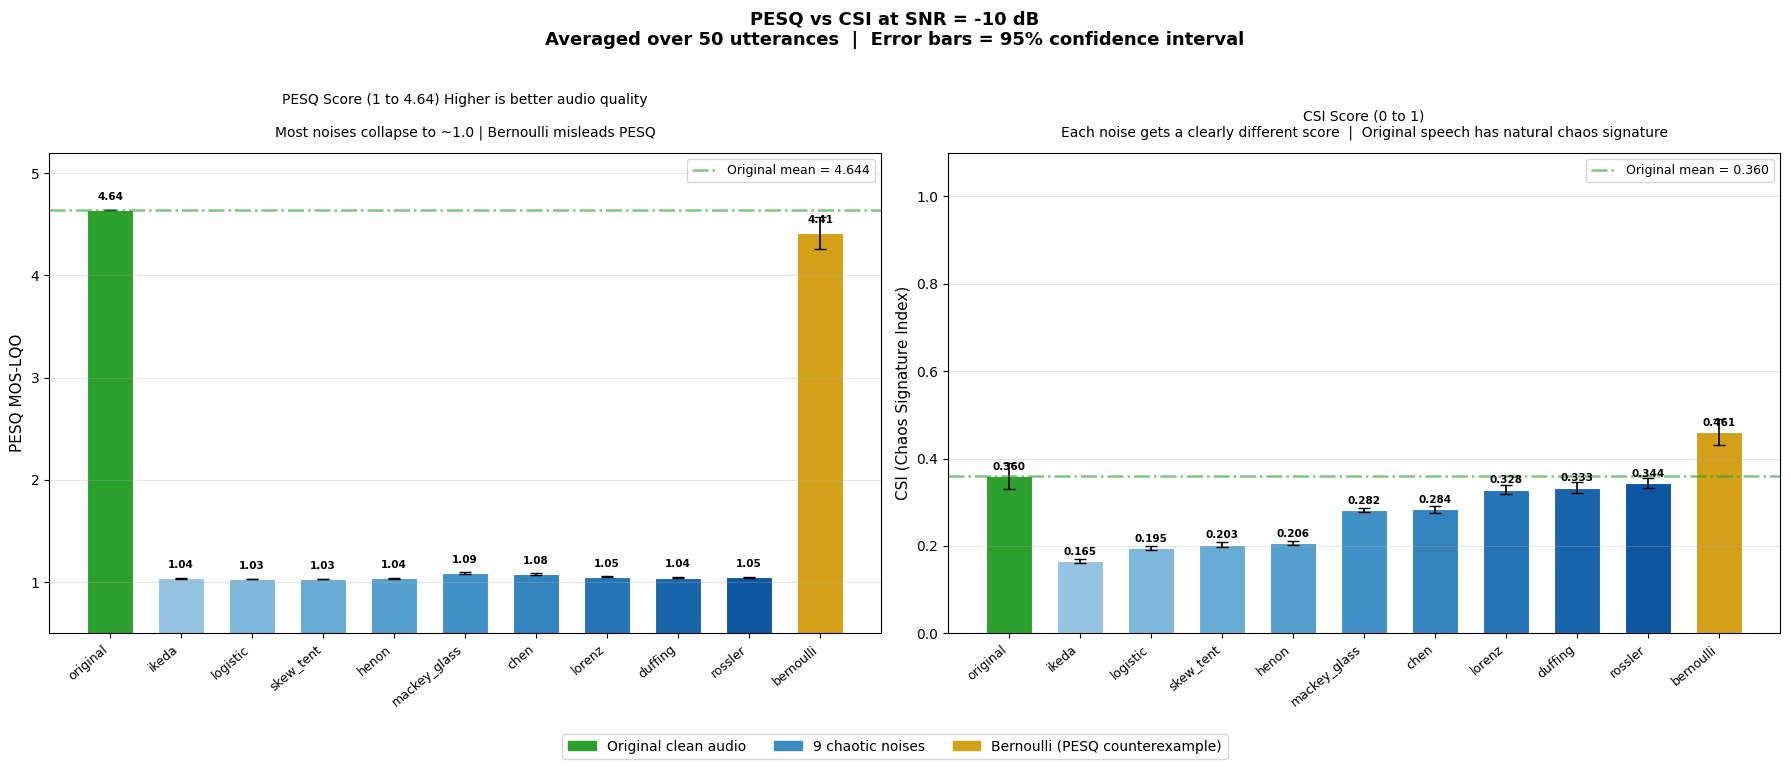


── Headline Numbers ──────────────────────────────────────────
At SNR = -10 dB, excluding Bernoulli:
  PESQ std across 9 noises : 0.0205  ← nearly flat
  CSI  std across 9 noises : 0.0646  ← clearly separated
  CSI is 3x more discriminative than PESQ

Bernoulli counterexample:
  PESQ = 4.413  ← PESQ says 'near clean'
  CSI  = 0.461   ← CSI correctly flags chaos
─────────────────────────────────────────────────────────────
Saved as final_result.png


In [42]:
snr_target = -10

# Extract raw floats for the plotting script
pesq_orig_mean = clean_df.loc[0, "PESQ_mean"]
pesq_orig_ci   = clean_df.loc[0, "PESQ_ci95"]
csi_orig_mean  = clean_df.loc[0, "CSI_mean"]
csi_orig_ci    = clean_df.loc[0, "CSI_ci95"]

# Data for plot
sub  = summary[summary["snr"] == snr_target].copy()
sub  = sub.sort_values("CSI_mean", ascending=True)

# Separate Bernoulli so it stands out
main = sub[sub["noise"] != "bernoulli"].reset_index(drop=True)
bern = sub[sub["noise"] == "bernoulli"].reset_index(drop=True)

# Combine: original first, then all noises sorted by CSI
noise_labels = ["original"] + main["noise"].tolist() + ["bernoulli"]
n_bars       = len(noise_labels)
x            = np.arange(n_bars)

# Build value arrays
pesq_vals = (
    [pesq_orig_mean]
    + main["PESQ_mean"].tolist()
    + [float(bern["PESQ_mean"])]
)
pesq_cis  = (
    [pesq_orig_ci]
    + main["PESQ_ci95"].tolist()
    + [float(bern["PESQ_ci95"])]
)
csi_vals  = (
    [csi_orig_mean]
    + main["CSI_mean"].tolist()
    + [float(bern["CSI_mean"])]
)
csi_cis   = (
    [csi_orig_ci]
    + main["CSI_ci95"].tolist()
    + [float(bern["CSI_ci95"])]
)

# Color scheme
#   original  → green
#   9 noises  → blue/red gradient
#   bernoulli → gold (special case)
def make_colors(n_middle):
    cols = (
        ["#2ca02c"]                                          # original = green
        + list(plt.cm.Blues(np.linspace(0.4, 0.85, n_middle)))  # noises
        + ["#d4a017"]                                        # bernoulli = gold
    )
    return cols

colors = make_colors(len(main))

# ── Figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

fig.suptitle(
    f"PESQ vs CSI at SNR = {snr_target} dB\n"
    f"Averaged over {len(df_orig)} utterances  |  "
    f"Error bars = 95% confidence interval",
    fontsize=13, fontweight="bold", y=1.02
)

# ── Left panel: PESQ ───────────────────────────────────────────────────
bars_l = axes[0].bar(
    x, pesq_vals, width=0.65,
    color=colors, edgecolor="white", linewidth=0.8,
    yerr=pesq_cis, capsize=4, error_kw=dict(elinewidth=1.2, ecolor="black")
)
axes[0].set_title(
    "PESQ Score (1 to 4.64) Higher is better audio quality\n\n"
    "Most noises collapse to ~1.0 | Bernoulli misleads PESQ",
    fontsize=10, pad=12
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(noise_labels, rotation=40, ha="right", fontsize=9)
axes[0].set_ylabel("PESQ MOS-LQO", fontsize=11)
axes[0].set_ylim(0.5, 5.2)
axes[0].axhline(pesq_orig_mean, color="#2ca02c", linestyle="-.",
                linewidth=1.8, alpha=0.6, label=f"Original mean = {pesq_orig_mean:.3f}")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)

# Value labels
for bar, val in zip(bars_l, pesq_vals):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.08,
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=7.5, fontweight="bold"
    )

# ── Right panel: CSI ───────────────────────────────────────────────────
bars_r = axes[1].bar(
    x, csi_vals, width=0.65,
    color=colors, edgecolor="white", linewidth=0.8,
    yerr=csi_cis, capsize=4, error_kw=dict(elinewidth=1.2, ecolor="black")
)
axes[1].set_title(
    "CSI Score (0 to 1)\n"
    "Each noise gets a clearly different score  |  Original speech has natural chaos signature",
    fontsize=10, pad=12
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(noise_labels, rotation=40, ha="right", fontsize=9)
axes[1].set_ylabel("CSI (Chaos Signature Index)", fontsize=11)
axes[1].set_ylim(0.0, 1.1)
axes[1].axhline(csi_orig_mean, color="#2ca02c", linestyle="-.",
                linewidth=1.8, alpha=0.6, label=f"Original mean = {csi_orig_mean:.3f}")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(fontsize=9)

# Value labels
for bar, val in zip(bars_r, csi_vals):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=7.5, fontweight="bold"
    )

# ── Shared legend ──────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color="#2ca02c", label="Original clean audio"),
    mpatches.Patch(color=plt.cm.Blues(0.65), label="9 chaotic noises"),
    mpatches.Patch(color="#d4a017", label="Bernoulli (PESQ counterexample)"),
]
fig.legend(
    handles=legend_patches,
    loc="lower center", ncol=3,
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, -0.06)
)

plt.tight_layout()
plt.savefig("final_result.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print the headline numbers ─────────────────────────────────────────
pesq_std_9 = np.std(main["PESQ_mean"])
csi_std_9  = np.std(main["CSI_mean"])

print("\n── Headline Numbers ──────────────────────────────────────────")
print(f"At SNR = {snr_target} dB, excluding Bernoulli:")
print(f"  PESQ std across 9 noises : {pesq_std_9:.4f}  ← nearly flat")
print(f"  CSI  std across 9 noises : {csi_std_9:.4f}  ← clearly separated")
print(f"  CSI is {csi_std_9/pesq_std_9:.0f}x more discriminative than PESQ")
print()
print(f"Bernoulli counterexample:")
print(f"  PESQ = {float(bern['PESQ_mean']):.3f}  ← PESQ says 'near clean'")
print(f"  CSI  = {float(bern['CSI_mean']):.3f}   ← CSI correctly flags chaos")
print("─────────────────────────────────────────────────────────────")
print("Saved as final_result.png")

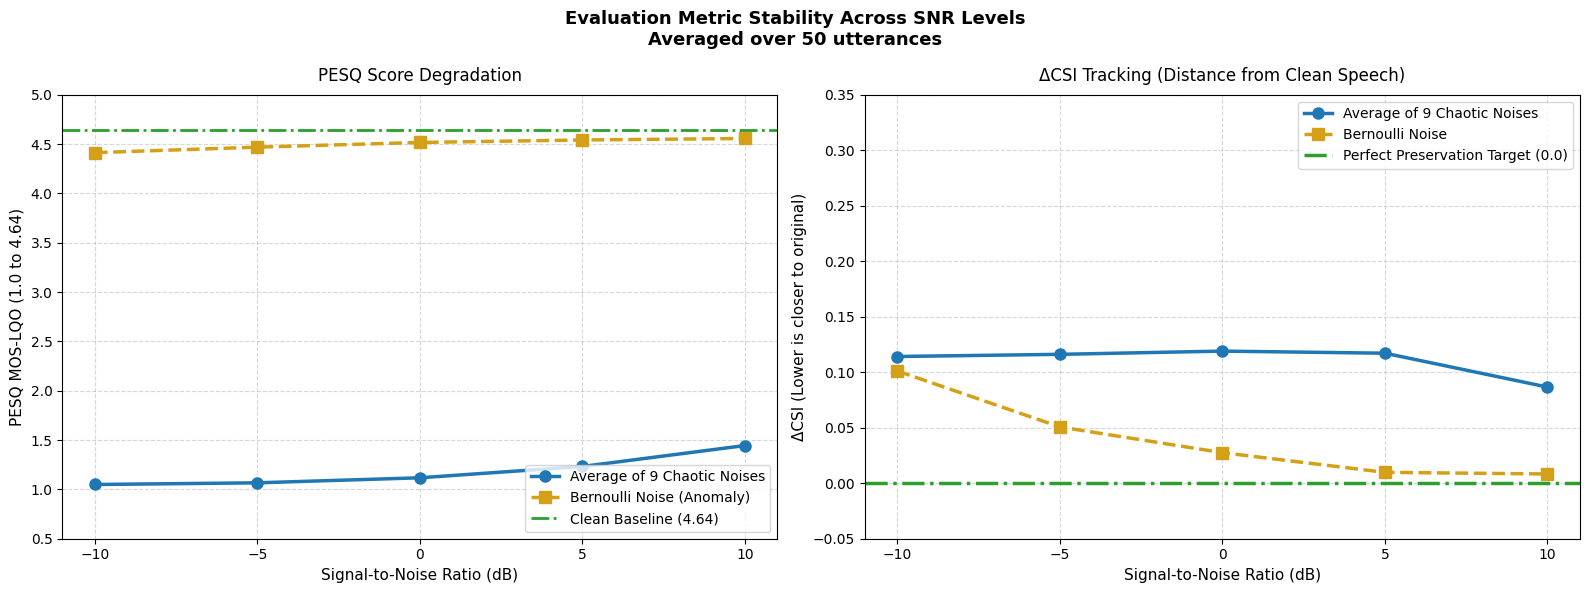

In [43]:
# 1. Merge and calculate Delta CSI
# We merge on 'file' to pair each noisy audio with its specific clean original
merged = df.merge(df_orig[['file', 'CSI', 'PESQ']], on='file', suffixes=('', '_clean'))
merged['Delta_CSI'] = np.abs(merged['CSI'] - merged['CSI_clean'])

# 2. Aggregate metrics by noise type and SNR
summary_snr = merged.groupby(['noise', 'snr']).agg(
    PESQ_mean=('PESQ', 'mean'),
    Delta_CSI_mean=('Delta_CSI', 'mean')
).reset_index()

# 3. Split the data for plotting
# Group the 9 continuous chaotic noises together, isolate Bernoulli
main_noises = summary_snr[summary_snr["noise"] != "bernoulli"]
bern_data   = summary_snr[summary_snr["noise"] == "bernoulli"].sort_values("snr")

avg_main = main_noises.groupby("snr").agg(
    PESQ_mean=("PESQ_mean", "mean"),
    Delta_CSI_mean=("Delta_CSI_mean", "mean")
).reset_index().sort_values("snr")

snr_levels = avg_main["snr"].values
pesq_clean_baseline = df_orig["PESQ"].mean()

# ── Figure Setup ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle(
    "Evaluation Metric Stability Across SNR Levels\n"
    "Averaged over 50 utterances",
    fontsize=13, fontweight="bold"
)

# ── Left Panel: PESQ Absolute Degradation ──────────────────────────────
axes[0].plot(
    snr_levels, avg_main["PESQ_mean"],
    marker='o', markersize=8, linewidth=2.5, color="#1f77b4",
    label="Average of 9 Chaotic Noises"
)
axes[0].plot(
    snr_levels, bern_data["PESQ_mean"],
    marker='s', markersize=8, linewidth=2.5, color="#d4a017", linestyle="--",
    label="Bernoulli Noise (Anomaly)"
)
axes[0].axhline(
    pesq_clean_baseline, color="#2ca02c", linestyle="-.", linewidth=2,
    label=f"Clean Baseline ({pesq_clean_baseline:.2f})"
)

axes[0].set_title("PESQ Score Degradation", pad=10)
axes[0].set_xlabel("Signal-to-Noise Ratio (dB)", fontsize=11)
axes[0].set_ylabel("PESQ MOS-LQO (1.0 to 4.64)", fontsize=11)
axes[0].set_ylim(0.5, 5.0)
axes[0].set_xticks(snr_levels)
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="lower right")

# ── Right Panel: Delta CSI (Recovery Tracking) ─────────────────────────
axes[1].plot(
    snr_levels, avg_main["Delta_CSI_mean"],
    marker='o', markersize=8, linewidth=2.5, color="#1f77b4",
    label="Average of 9 Chaotic Noises"
)
axes[1].plot(
    snr_levels, bern_data["Delta_CSI_mean"],
    marker='s', markersize=8, linewidth=2.5, color="#d4a017", linestyle="--",
    label="Bernoulli Noise"
)
axes[1].axhline(
    0.0, color="#2ca02c", linestyle="-.", linewidth=2.5,
    label="Perfect Preservation Target (0.0)"
)

axes[1].set_title("ΔCSI Tracking (Distance from Clean Speech)", pad=10)
axes[1].set_xlabel("Signal-to-Noise Ratio (dB)", fontsize=11)
axes[1].set_ylabel("ΔCSI (Lower is closer to original)", fontsize=11)
axes[1].set_ylim(-0.05, 0.35)
axes[1].set_xticks(snr_levels)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig("snr_degradation_delta.png", dpi=150, bbox_inches="tight")
plt.show()